# 02 · Preprocessing and feature selection

Fitted on the **80% training split (480 shows)** only; the 120-show holdout is never used here.

| Step | Method | Figure |
|---|---|---|
| Missing values | deterministic recovery in cleaning; median imputation kept as a safety net | 12 |
| Outliers | unit error fixed in cleaning; Tukey IQR winsorisation in the pipeline | 13 |
| Normalisation | z-score (StandardScaler) | 14 |
| Correlation / redundancy | Spearman correlation, variance inflation factors | 15 |
| Feature selection | FDR + mutual information (+ optional VIF rule) and the 5-D latent basis; strategy chosen by repeated CV | 16 |

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/tv-genre-classification


In [2]:
# Rebuild the cleaned data if it is missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
from src.features import build_features as bf
from src.utils import load_json
train, lab = make_dataset.load("train"), make_dataset.load("labelled")
spec = load_json(cfg.CLEANING_SPEC_FILE)
print(train.shape, train[cfg.TARGET].value_counts().to_dict())

(480, 16) {'Comedy': 294, 'Drama': 101, 'Reality': 85}


## 1. Missing values: exact recovery beats imputation
Observed J values are hidden for 20% of shows and recovered three ways.

,method,MAE
0,Median,1.059725e+00
1,KNN (k=5),5.612262e-01
2,Exact formula,7.738779e-16


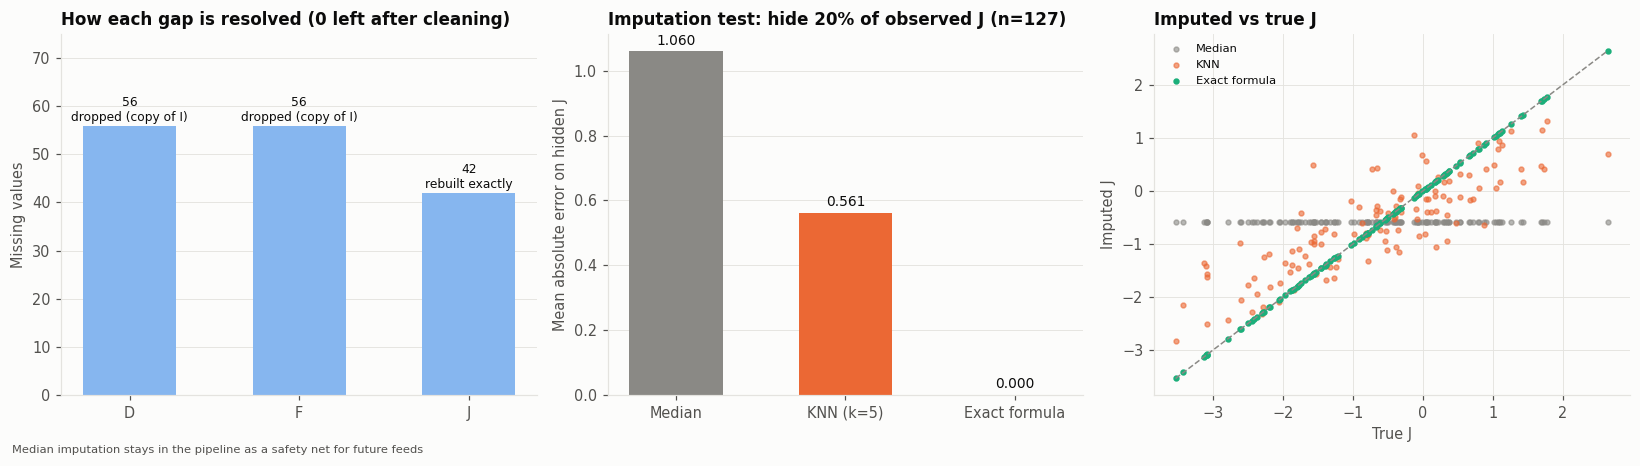

In [3]:
imp = bf.plot_missing_strategy(lab, spec)
imp

## 2. Outliers

,feature,lower_fence,upper_fence,n_outliers,pct_outliers,n_abs_z_gt_3
9,M,-2.534,3.885,10,2.083,4
3,E,-2.498,2.345,8,1.667,3
0,A,-3.168,4.543,6,1.250,6
11,O,-2.487,2.568,5,1.042,1
4,G,-2.665,2.703,4,0.833,2
2,C,-3.180,3.396,4,0.833,0
8,L,-6.445,4.750,4,0.833,1
7,J,-4.260,3.130,3,0.625,3
5,H,-2.606,2.678,3,0.625,3
6,I,-4.631,3.773,3,0.625,0


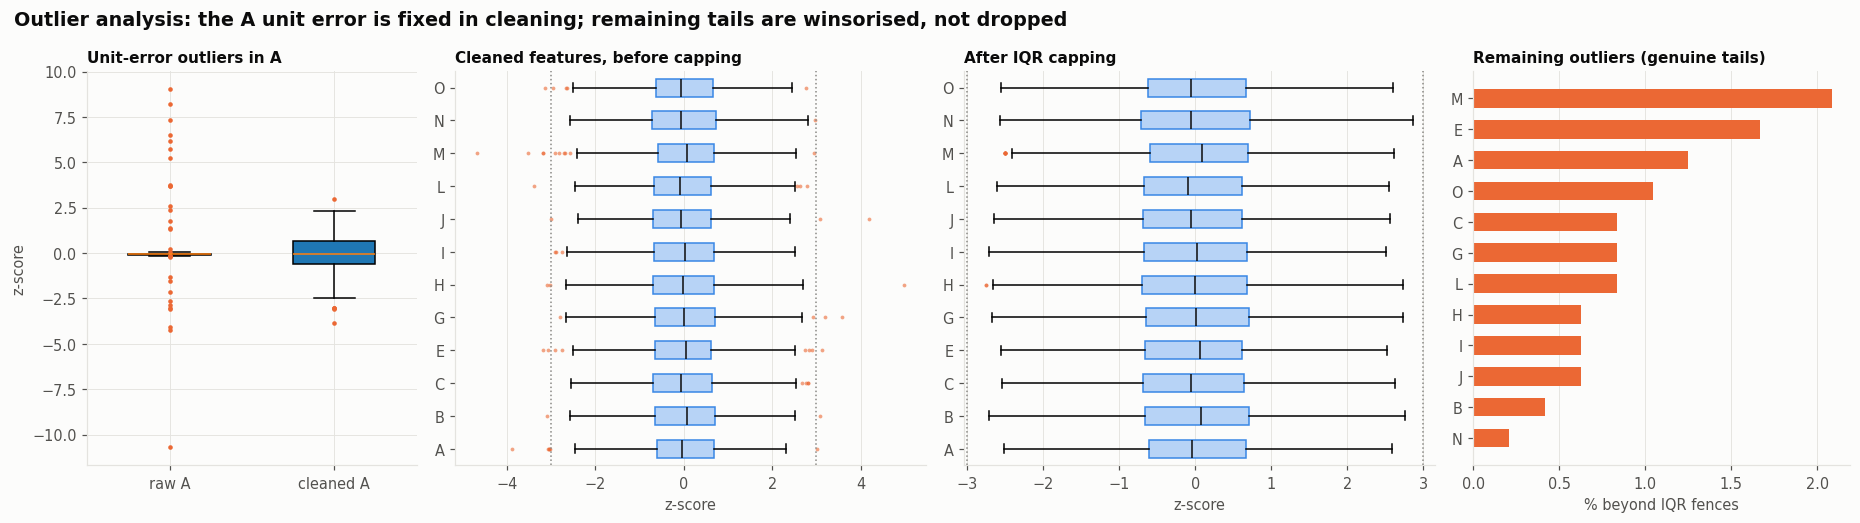

In [4]:
ot = bf.outlier_table(train)
bf.plot_outliers(train, ot)
ot.round(3)

## 3. Feature selection

In [5]:
sel = bf.select_features(train)
print("chosen strategy:", sel["strategy"], "->", sel["selected"])
sel["table"][["feature", "kruskal_p", "q_value", "mutual_info", "vif_among_candidates", "reason"]].round(4)

13:21:42 | INFO    | src.features.build_features | Linear block ['B', 'C', 'I', 'L', 'M', 'N', 'J'] has rank 5; basis ['C', 'I', 'L', 'M', 'N'] reproduces: {'B': 1.0, 'C': 1.0, 'I': 1.0, 'L': 1.0, 'M': 1.0, 'N': 1.0, 'J': 1.0, 'A': 0.9962}


chosen strategy: S5 latent basis -> ['C', 'I', 'L', 'M', 'N']


,feature,kruskal_p,q_value,mutual_info,vif_among_candidates,reason
9,M,0.0008,0.0016,0.0785,1939.5069,kept
2,C,0.0003,0.0006,0.0654,275.3193,kept
0,A,0.0000,0.0000,0.0458,266.5065,dropped
1,B,0.9256,0.9256,0.0414,NaN,dropped: FDR q >= 0.05
8,L,0.0010,0.0016,0.0329,10044.0133,kept
10,N,0.0000,0.0000,0.0317,6184.2611,kept
4,G,0.0138,0.0207,0.0159,1.0131,dropped
3,E,0.2187,0.2915,0.0151,NaN,dropped: FDR q >= 0.05
7,J,0.0000,0.0000,0.0109,3932.1674,dropped: exact linear redundancy (VIF)
5,H,0.4810,0.5772,0.0000,NaN,dropped: FDR q >= 0.05


In [6]:
sel["comparison"].pivot_table(index="strategy", columns="reference_model", values="score").round(4)

reference_model,Gaussian mixture (2 per genre),"SVM-RBF (C=10, balanced)","XGBoost (depth 3, 300 trees)"
strategy,,,
S1 FDR + MI + VIF,0.8751,0.7711,0.7237
S2 FDR + MI,0.8767,0.7836,0.7336
S3 FDR only,0.8713,0.7913,0.7331
S4 all cleaned,0.8328,0.7417,0.7358
S5 latent basis,0.8848,0.7775,0.6746


In [7]:
pd.Series(sel["latent_basis"]["r2_from_basis"], name="R2 from C, I, L, M, N").round(5)

B    1.00000
C    1.00000
I    1.00000
L    1.00000
M    1.00000
N    1.00000
J    1.00000
A    0.99624
Name: R2 from C, I, L, M, N, dtype: float64

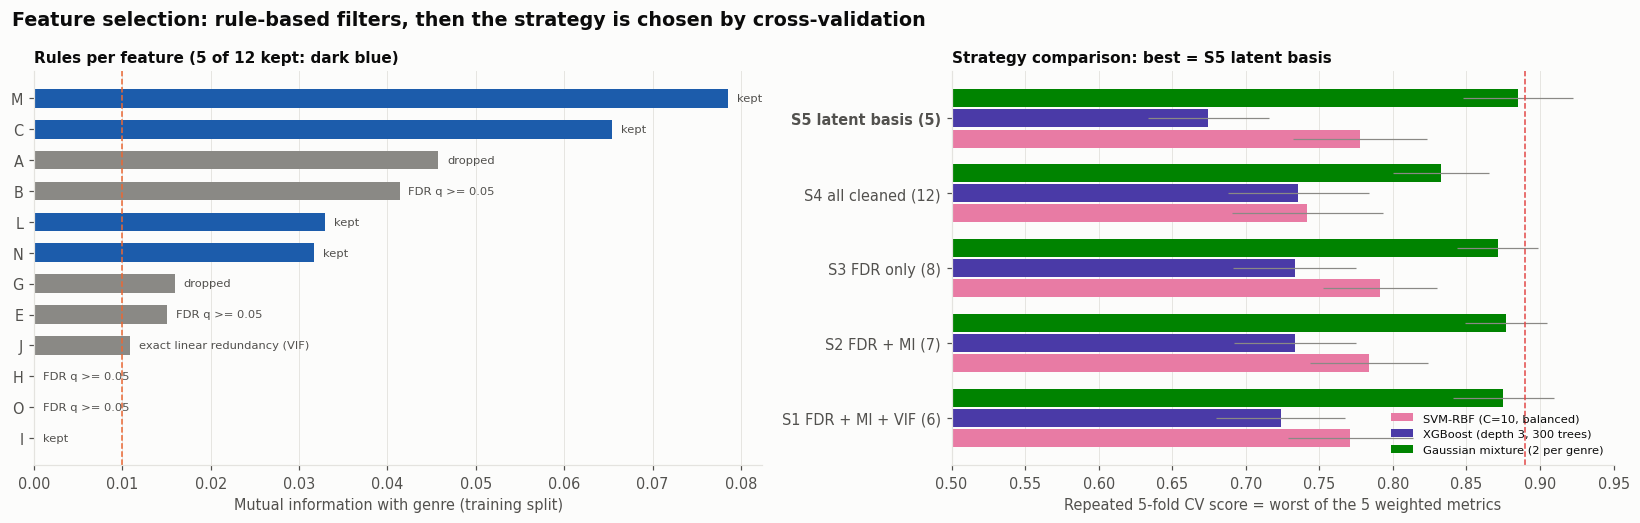

In [8]:
bf.plot_feature_selection(sel["table"], sel["comparison"], sel["strategy"]);

The score is the **worst of the five weighted target metrics** (Accuracy, Sensitivity, Specificity, Precision, F1) in repeated CV. The rule-based filters (S1-S3) drop I because its marginal mutual information with genre is ~0, yet I is needed: B, C, I, J, L, M, N span exactly 5 dimensions and C, I, L, M, N reproduce B and J with R² = 1. **S5 (latent basis C, I, L, M, N)** with the Gaussian-mixture reference scores highest, so it is used by every classifier. A, the reconstructed J and the noise columns add nothing once the basis is complete.

## 4. Correlation and variance inflation

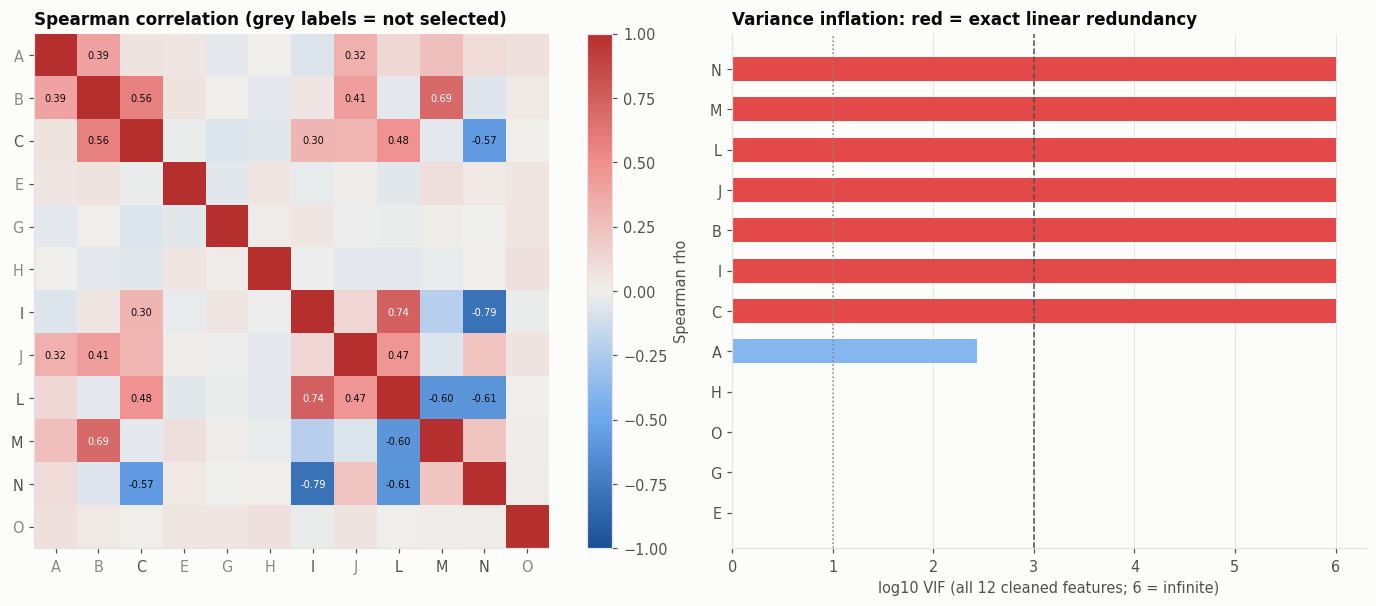

In [9]:
bf.plot_correlation_vif(train, sel);

## 5. z-score normalisation

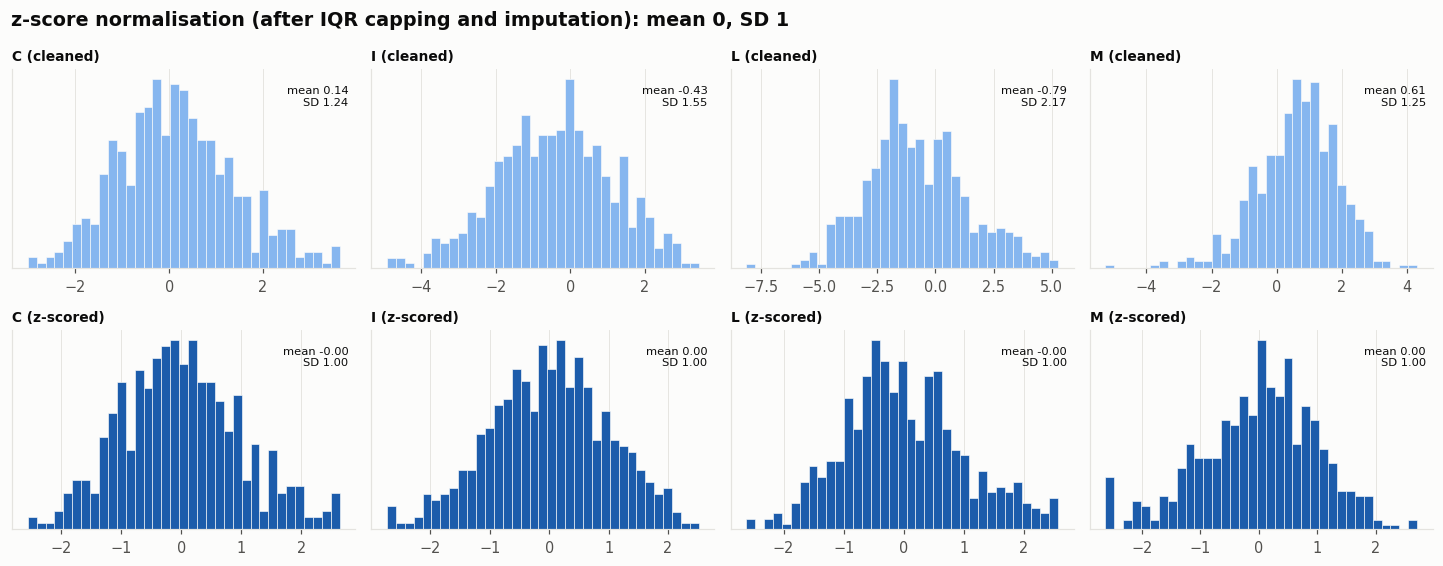

In [10]:
bf.plot_zscore(train, sel["selected"]);

In [11]:
prep = bf.build_preprocessor().fit(train[sel["selected"]])
Xt = pd.DataFrame(prep.transform(train[sel["selected"]]), columns=sel["selected"])
Xt.describe().T[["mean", "std", "min", "max"]].round(3)

,mean,std,min,max
C,-0.0,1.001,-2.555,2.638
I,0.0,1.001,-2.728,2.517
L,-0.0,1.001,-2.624,2.569
M,0.0,1.001,-2.627,2.710
N,-0.0,1.001,-2.576,2.875


In [12]:
_ = bf.run(); plt.close("all")     # writes selected_features.json and all figures (as `make features`)
print(open(cfg.SELECTED_FEATURES_FILE).read()[:400])

13:22:33 | INFO    | src.features.build_features | Linear block ['B', 'C', 'I', 'L', 'M', 'N', 'J'] has rank 5; basis ['C', 'I', 'L', 'M', 'N'] reproduces: {'B': 1.0, 'C': 1.0, 'I': 1.0, 'L': 1.0, 'M': 1.0, 'N': 1.0, 'J': 1.0, 'A': 0.9962}


13:23:22 | INFO    | src.features.build_features | Strategy comparison:
                   n_features   score
strategy                             
S1 FDR + MI + VIF           6  0.8751
S2 FDR + MI                 7  0.8767
S3 FDR only                 8  0.8713
S4 all cleaned             12  0.8328
S5 latent basis             5  0.8848


13:23:22 | INFO    | src.features.build_features | Chosen S5 latent basis -> 5 features: ['C', 'I', 'L', 'M', 'N']


{
  "selected_features": [
    "C",
    "I",
    "L",
    "M",
    "N"
  ],
  "strategy": "S5 latent basis",
  "strategies": {
    "S1 FDR + MI + VIF": [
      "A",
      "C",
      "G",
      "L",
      "M",
      "N"
    ],
    "S2 FDR + MI": [
      "A",
      "C",
      "G",
      "J",
      "L",
      "M",
      "N"
    ],
    "S3 FDR only": [
      "A",
      "C",
      "G",
      "I",
     
